In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from matplotlib import animation
from IPython.display import HTML

os.chdir("../src")
os.getcwd()

from simulator.gca import Maxflow2GCA, VesselsGCA, VesselsGCASingle

%load_ext autoreload
%autoreload 2

/home/flyingleafe/Job/Clique/simple-eigentrust/python/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def graph_node_attrs(G, *attrs):
    n = G.number_of_nodes()
    attr_arrays = {}
    for attr in attrs:
        attr_arrays[attr] = np.zeros(n)

    for node, dd in G.nodes(data=True):
        for attr in attrs:
            attr_arrays[attr][node] = getattr(dd["state"], attr)

    return attr_arrays

def graph_sequence_node_attrs(Gs, *attrs):
    dicts = [graph_node_attrs(G, *attrs) for G in Gs]
    return {
        k: np.vstack([d[k] for d in dicts])
        for k in dicts[0].keys()
    }


def graph_balances_and_credit_limits(G):
    vals = graph_node_attrs(G, 'balance', 'credit_limit')
    return vals['balance'], vals['credit_limit']

def sequence_balances_and_credit_limits(Gs):
    bss, lss = zip(*map(graph_balances_and_credit_limits, Gs))
    return np.vstack(bss), np.vstack(lss)


def plot_balances_and_credit_limits(balances, limits):
    assert len(balances) == len(limits)
    x = np.arange(len(balances))
    plt.bar(x, balances, label='Available balances')
    plt.bar(x, limits, bottom=balances, label='Credit limits')
    plt.legend()
    plt.show()


def animated_bar_plot(Xs):
    fig = plt.figure()
    T, n = Xs.shape
    barcollection = plt.bar(np.arange(n), Xs[0])

    def _animate(i):
        for j, b in enumerate(barcollection):
            b.set_height(Xs[i, j])
    
    anim = animation.FuncAnimation(fig, _animate, repeat=False,blit=False,frames=T)
    return HTML(anim.to_jshtml())

In [3]:
def simulate_and_animate(G, init_balances, n_steps=100, **kwargs):
    gca = VesselsGCA(G, balance_distribution=init_balances, **kwargs)
    records = gca.run_simulation(n_steps)

    phantom_balances = graph_sequence_node_attrs([d['graph'] for d in records[0]], 'phantom_balance')['phantom_balance']
    print(phantom_balances[-1, :])
    return phantom_balances, animated_bar_plot(phantom_balances)


def simulate_vessels(G, init_balances, n_steps=100, **kwargs):
    gca = VesselsGCA(G, balance_distribution=init_balances, **kwargs)
    records = gca.run_simulation(n_steps)

    phantom_excesses = graph_sequence_node_attrs([d['graph'] for d in records[0]], 'phantom_balance')['phantom_balance']
    print(phantom_excesses[-1, :])
    return phantom_excesses, records


def simulate_single_user_debt(G, init_balances, n_steps=100, n_user=0, **kwargs):
    gca = VesselsGCASingle(G, balance_distribution=init_balances, debting_node=n_user, **kwargs)
    records = gca.run_simulation(n_steps)

    balances = graph_sequence_node_attrs([d['graph'] for d in records[0]], 'balance')['balance']
    print(balances[-1, :])
    return balances, records

In [4]:
mini_graph = nx.DiGraph()

mini_graph.add_node(0)
mini_graph.add_node(1)

mini_graph.add_edge(0, 1, capacity=5, height=90000)

init_balances = {0: 100000, 1: 1000}

#simulate_and_animate(mini_graph, init_balances, fractional_banking_coeff=0.1)

hmm, records = simulate_single_user_debt(mini_graph, init_balances, n_user=1)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 100, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (100, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 495.25it/s]


Execution Method: single_proc_exec


Flattening results:   1%|▎                                   | 1/101 [00:00<00:00, 207.63it/s]

Total execution time: 0.04s
[89998.91938382 11001.08061618]


In [5]:
def draw_with_edge_colors(G):
    ccs = [('r' if d["state"].is_open else 'k') for u, v, d in G.edges(data=True)]
    nx.draw_kamada_kawai(G, edge_color=ccs, with_labels=True)
    

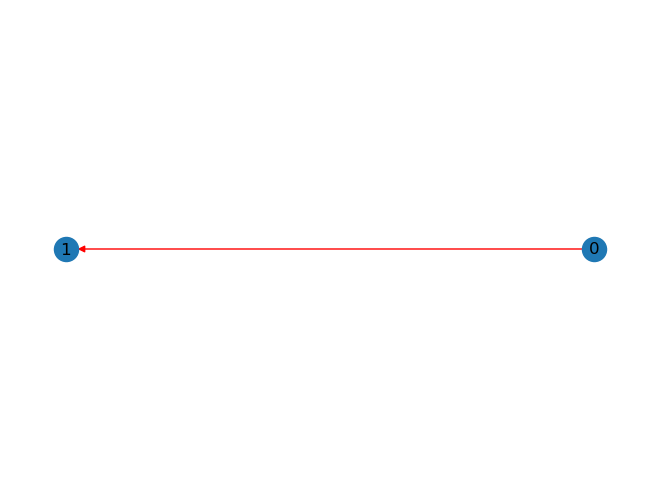

In [6]:
draw_with_edge_colors(records[0][1]['graph'])

In [47]:
def softmax(x, t=1.0):
    return np.exp(x/t)/sum(np.exp(x/t))

def generate_pareto_graph_vessels(N, total_money=1000000, avg_degree=4):
    balances = np.random.pareto(2.0, size=N)
    normalized_balances = balances / np.sum(balances)
    balances = normalized_balances * total_money

    G = nx.DiGraph()
    sorted_by_richness = np.argsort(balances)[::-1]

    for n in sorted_by_richness:
        G.add_node(n)

    for i, n in enumerate(sorted_by_richness):
        moneys = balances[n]
        degree = np.random.randint(avg_degree-2, avg_degree+2)

        mean_height = 0.5 * moneys
        sigma_height = 0.2 * mean_height

        others = np.concatenate([sorted_by_richness[:i], sorted_by_richness[i+1:]])
        assert len(others) == N-1
        other_balances = balances[others]

        closeness_in_richness = np.abs(other_balances - moneys) + 0.1
        p = softmax(1 / closeness_in_richness, t=2.0)

        out_neighbors = np.random.choice(others, size=degree, p=p, replace=False)

        for other in out_neighbors:
            G.add_edge(
                n, other,
                capacity=N*normalized_balances[n],
                height=(sigma_height*np.random.rand() + mean_height)
            )
    
    return G, balances

def plot_timeframes(res, timeframes):
    N = len(timeframes)
    xs = np.arange(results.shape[1])
    orig = res[0]
    
    fig, axes = plt.subplots(nrows=N, ncols=1, figsize=(10, 2*N))

    for i in range(N):
        frame = timeframes[i]
        plt.sca(axes[i])
        plt.bar(xs, results[0], alpha=0.5)
        plt.bar(xs, results[frame], alpha=0.5)
        plt.title(f"Time step {frame}")

    fig.tight_layout()
    plt.show()


# tak blyat

In [8]:
mini_graph = nx.DiGraph()

mini_graph.add_node(0)
mini_graph.add_node(1)
mini_graph.add_node(2)
mini_graph.add_node(3)
mini_graph.add_node(4)

mini_graph.add_edge(0, 1, capacity=5, height=60000)
mini_graph.add_edge(1, 2, capacity=5, height=30000)
mini_graph.add_edge(2, 3, capacity=5, height=10000)
mini_graph.add_edge(3, 4, capacity=5, height=5000)

init_balances = {0: 100000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}

#simulate_and_animate(mini_graph, init_balances, fractional_banking_coeff=0.1)

hmm, records = simulate_single_user_debt(mini_graph, init_balances, n_user=4)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 100, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (100, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 614.73it/s]


Execution Method: single_proc_exec


Flattening results:   1%|▎                                   | 1/101 [00:00<00:00, 447.39it/s]

Total execution time: 0.05s
[59997.01545475 29995.76188647  9994.18789642  3013.03476236
  1000.        ]


<BarContainer object of 5 artists>

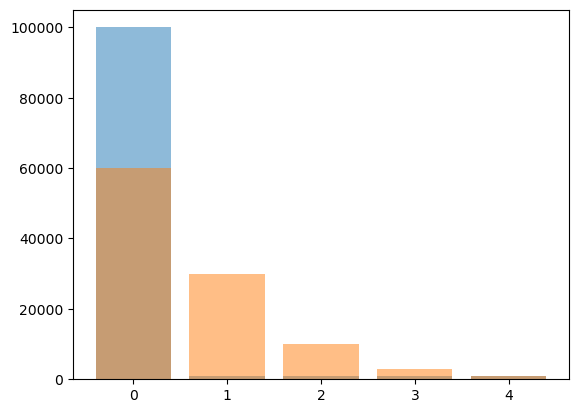

In [9]:
plt.bar(np.arange(hmm.shape[1]), hmm[0], alpha=0.5)
plt.bar(np.arange(hmm.shape[1]), hmm[-1], alpha=0.5)

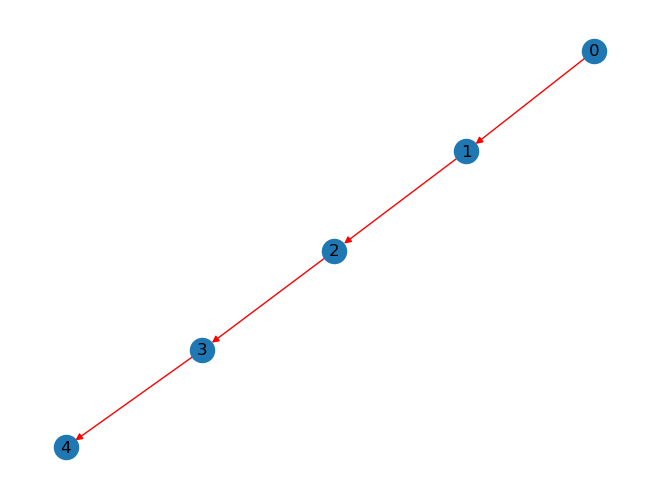

In [10]:
draw_with_edge_colors(records[0][4]['graph'])

In [30]:
G, balances = generate_pareto_graph_vessels(100)

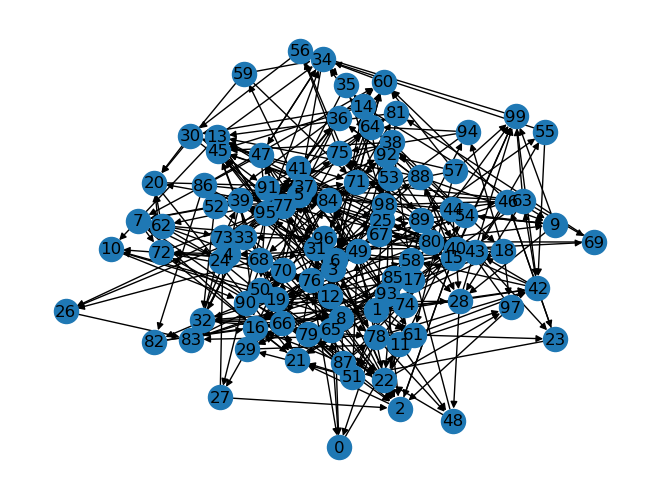

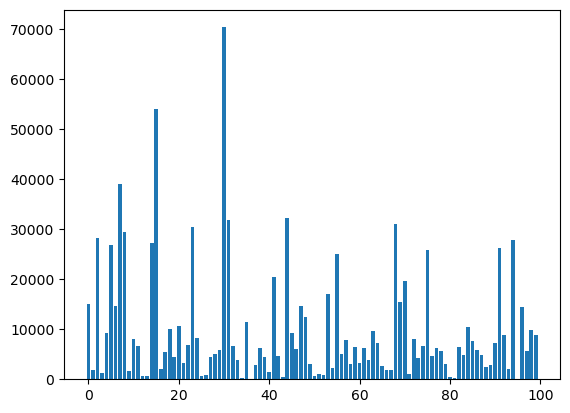

999999.9999999998


In [31]:
nx.draw(G, with_labels=True)
plt.show()
plt.bar(np.arange(len(balances)), balances)
plt.show()
print(np.sum(balances))

In [32]:
balances_dict = {n: balances[n] for n in range(len(balances))}

In [33]:
results, records = simulate_vessels(G, balances_dict, n_steps=500)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (500, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 298.53it/s]

Execution Method: single_proc_exec



Flattening results:   0%|                                    | 1/501 [00:00<00:00, 569.18it/s]

Total execution time: 6.18s
[ 8646.33956498  8650.22220099 14949.78352202  8643.54350868
  8644.36345879 14722.79211588 10453.75736331 20148.48063408
 15123.7859251   8657.32995317  8594.0987619   8644.48541632
  8639.21428459  8661.14522599 13899.9547229  27084.55846774
  8669.63449885  8598.88443646  8644.62177494  8592.04479837
  8643.64009638  8654.51517368  8649.6287515  16379.52228874
  5335.01351643  8846.93583844  8650.16155985  8587.18729953
  8665.54042974  8642.99352124 35972.66503432 16378.24974607
  8650.72094626  8647.89733821  8990.26519436  8589.88149217
  8655.05793737  8642.55175583  8643.88381811  8646.80173237
  8668.38344814 12033.1448681   8671.54463246 10465.08425976
 16516.40015994  8646.24746632 10469.73909163  8663.61149712
  8655.60556795  8641.88139819 10396.6145284   8641.57898335
  8641.23765223  9105.09447808  8659.29240707 12738.87528443
 10534.60475304  6015.46634524  8663.63390886  8649.36166328
 10543.72354231  8647.87438609  5334.01641778  8677.32429

<BarContainer object of 100 artists>

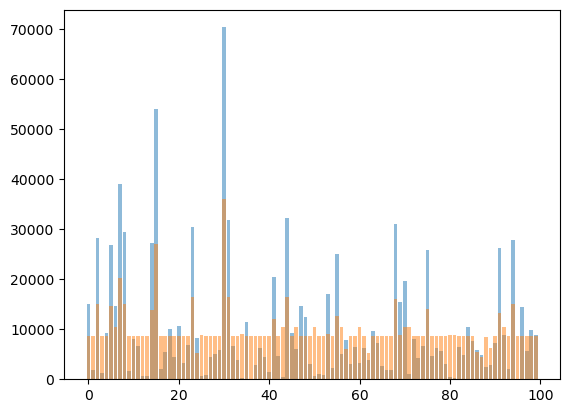

In [34]:
plt.bar(np.arange(results.shape[1]), results[0], alpha=0.5)
plt.bar(np.arange(results.shape[1]), results[500], alpha=0.5)

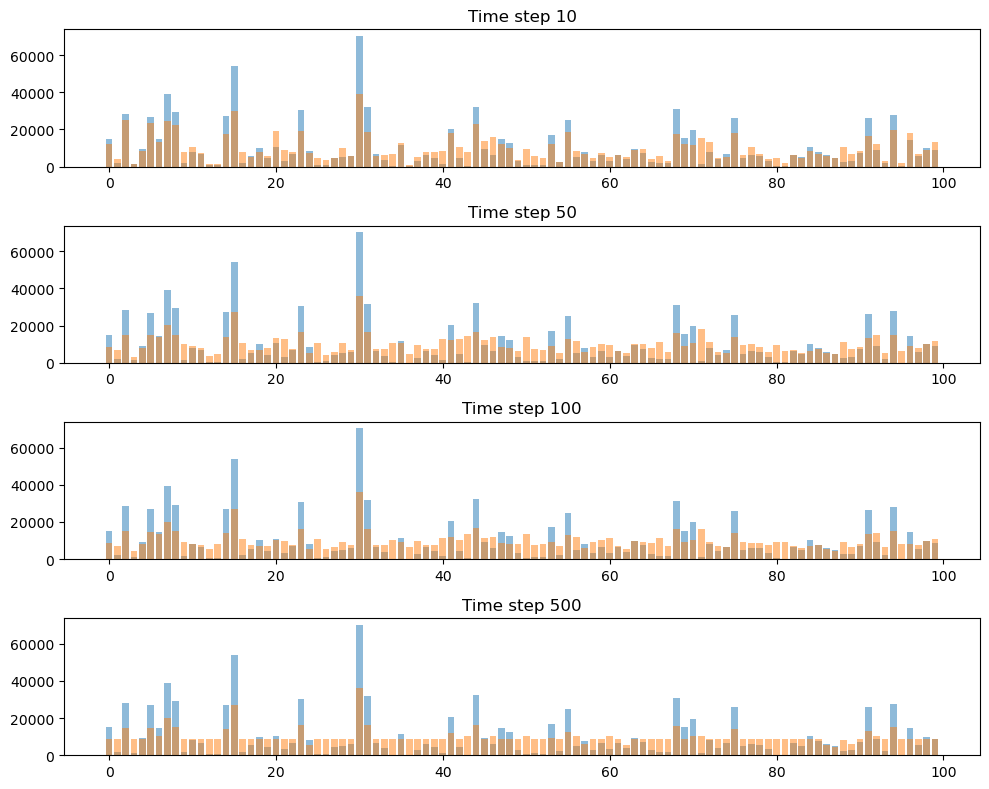

In [50]:
plot_timeframes(results, [10, 50, 100, 500])

In [52]:
max_debt_results = np.zeros((501, 100))

for n_user in range(100):
    results, records = simulate_single_user_debt(G, balances_dict, n_steps=500, n_user=n_user)
    max_debt_results[:, n_user] = results[:, n_user]


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (500, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 442.25it/s]

Execution Method: single_proc_exec



Flattening results:   0%|                                    | 1/501 [00:00<00:00, 631.67it/s]


Total execution time: 7.61s
[14967.49144613  1945.98376163 28317.43151992  1282.92334932
  9270.36663056 26879.50735188 14584.96612529 39078.66761589
 29332.7229064   1639.5056298   8034.59529383  6712.18293188
   625.10440365   601.6565741  27171.37071556 54056.24727251
  2009.51110011  5419.89029287 10080.80510241  4417.49249181
 10559.40112639  3241.76750961  6811.16596031 30425.17106213
  8252.9420818    618.86780837   924.11530241  4393.80322318
  5105.90840489  5860.44500788 70326.18473958 31894.82479964
  6593.98764334  3778.96506597   278.82547257 11469.15653081
    95.44765316  2753.0455115   6330.34545118  4395.90445477
  1391.56701229 20411.25753441  4555.70145304   386.11878907
 32241.14386103  9321.29594657  6116.59611688 14574.93053317
 12512.21852042  3016.68303062   702.02466713  1038.11980826
   932.9254273  17032.18041678  2224.76995301 24980.87344801
  5123.12146989  7830.45299664  3100.26474239  6433.70764237
  3242.30616053  6345.72602294  3813.8863854   9568.44390

...

Total execution time: 7.98s
[14967.49144613  1945.98376163 28317.43151992  1282.92334932
  9270.36663056 26879.50735188 14584.96612529 39078.66761589
 29332.7229064   1639.5056298   8034.59529383  6712.18293188
   625.10440365   601.6565741  16183.01151404 54056.24727251
  2009.51110011  5419.89029287 10080.80510241  4417.49249181
 10559.40112639  3241.76750961  6811.16596031 30425.17106213
  8252.9420818    618.86780837   924.11530241  4393.80322318
  5105.90840489  5860.44500788 70326.18473958 31894.82479964
  6593.98764334  3778.96506597   278.82547257 16185.58542334
    95.44765316  2753.0455115   6330.34545118  4395.90445477
  1391.56701229 20411.25753441  4555.70145304   386.11878907
 32241.14386103  9321.29594657  6116.59611688 14574.93053317
 12512.21852042  3016.68303062   702.02466713  1038.11980826
   932.9254273  17032.18041678  2224.76995301 24980.87344801
  5123.12146989  7830.45299664  3100.26474239  6433.70764237
  3242.30616053  6345.72602294  3813.8863854   9568.44390

Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 608.13it/s]


Execution Method: single_proc_exec


Flattening results:   0%|                                    | 1/501 [00:00<00:00, 654.44it/s]

Total execution time: 9.37s
[14967.49144613  1945.98376163 28317.43151992  1282.92334932
  9270.36663056 26879.50735188 14584.96612529 39078.66761589
 29332.7229064   1639.5056298   8034.59529383  6712.18293188
   625.10440365   601.6565741  14609.42443806 31390.07539484
  2009.51110011  5419.89029287 10080.80510241  4417.49249181
 10559.40112639  3241.76750961  6811.16596031 30425.17106213
  8252.9420818    618.86780837   924.11530241  4393.80322318
  5105.90840489  5860.44500788 70326.18473958 31894.82479964
  6593.98764334  3778.96506597   278.82547257 14480.5327357
    95.44765316  2753.0455115   6330.34545118  4395.90445477
  1391.56701229 20411.25753441  4555.70145304   386.11878907
 32241.14386103  9321.29594657  6116.59611688 14574.93053317
 12512.21852042  3016.68303062   702.02466713  1038.11980826
   932.9254273  17032.18041678  2224.76995301 24980.87344801
  5123.12146989  7830.45299664  3100.26474239  6433.70764237
  3242.30616053  6345.72602294  3813.8863854  14484.742468

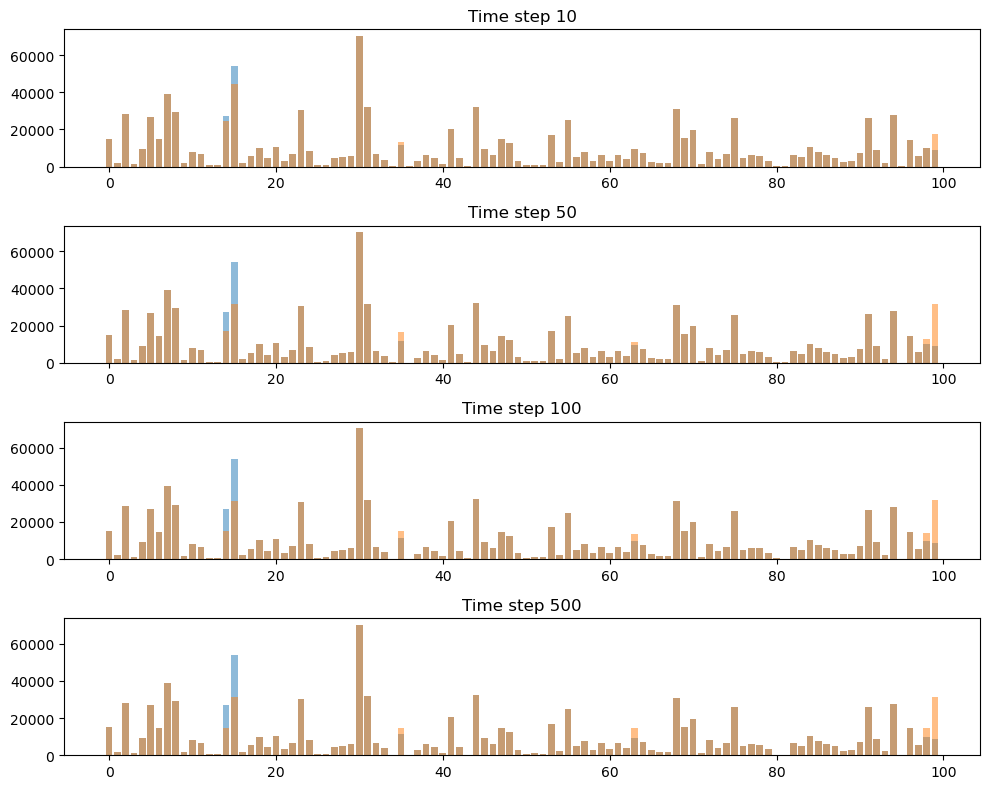

In [53]:
plot_timeframes(max_debt_results, [10, 50, 100, 500])

In [56]:
max_debt_results[:, ]

array([14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
       14967.49144613, 14967.49144613, 14967.49144613, 14967.49144613,
      

In [64]:
results, records = simulate_single_user_debt(G, balances_dict, n_steps=500, n_user=20)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (500, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 775.14it/s]

Execution Method: single_proc_exec



Flattening results:   0%|                                    | 1/501 [00:00<00:00, 692.36it/s]

Total execution time: 7.00s
[14967.49144613  1945.98376163 28317.43151992  1282.92334932
  9270.36663056 26879.50735188 14584.96612529 39078.66761589
 29332.7229064   1639.5056298   8034.59529383  6712.18293188
   625.10440365   601.6565741  27171.37071556 54056.24727251
  2009.51110011  5419.89029287 10080.80510241  4417.49249181
 40633.04920214  3241.76750961  6811.16596031 30425.17106213
  8252.9420818    618.86780837   924.11530241  4393.80322318
  5105.90840489  5860.44500788 40252.53666382 31894.82479964
  6593.98764334  3778.96506597   278.82547257 11469.15653081
    95.44765316  2753.0455115   6330.34545118  4395.90445477
  1391.56701229 20411.25753441  4555.70145304   386.11878907
 32241.14386103  9321.29594657  6116.59611688 14574.93053317
 12512.21852042  3016.68303062   702.02466713  1038.11980826
   932.9254273  17032.18041678  2224.76995301 24980.87344801
  5123.12146989  7830.45299664  3100.26474239  6433.70764237
  3242.30616053  6345.72602294  3813.8863854   9568.44390

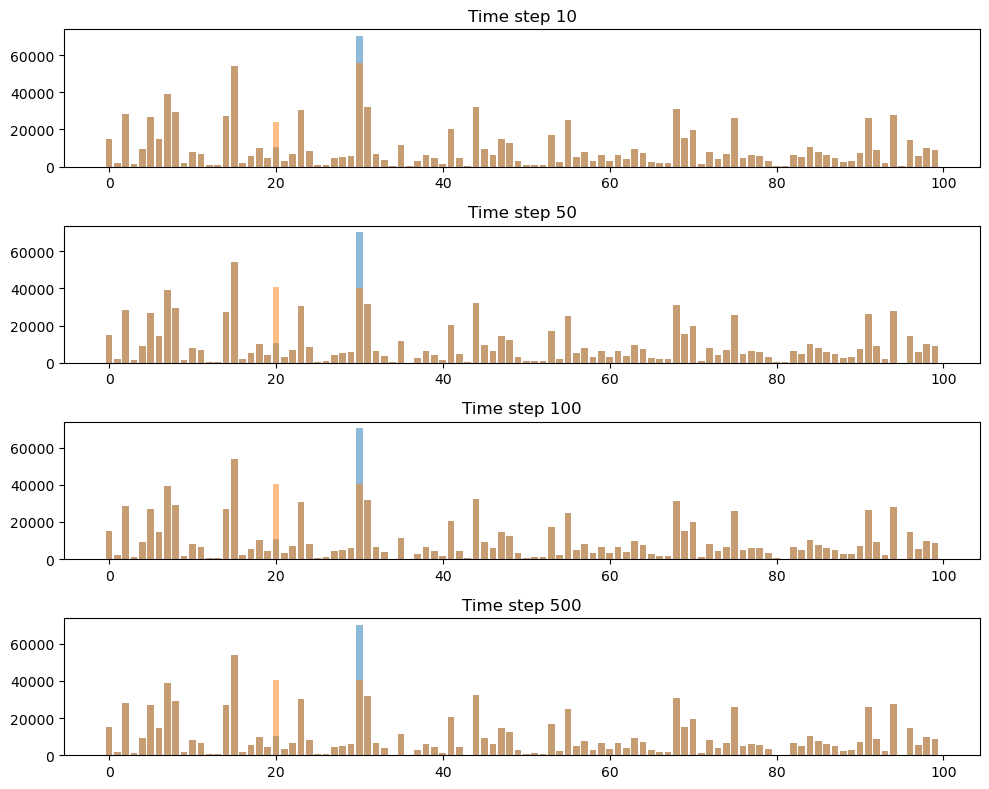

In [65]:
plot_timeframes(results, [10, 50, 100, 500])

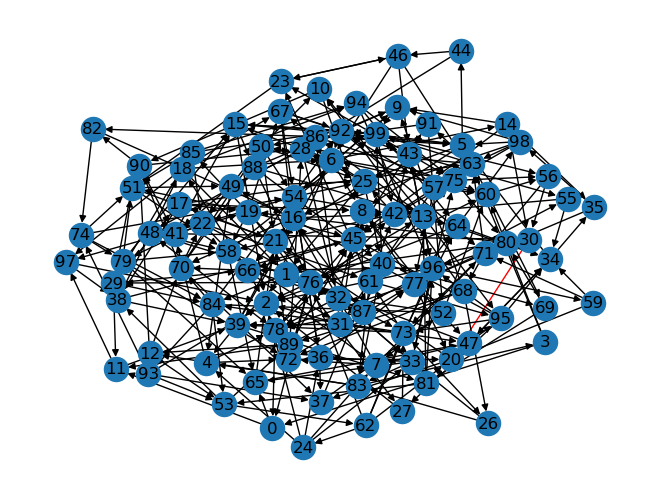

In [66]:
draw_with_edge_colors(records[0][-1]['graph'])

In [57]:
results[0][20]

44121491.25260995

In [66]:
all_results = []
for i in range(30):
    results, records = simulate_single_user_debt(G, balances_dict, n_steps=500, n_user=i)
    all_results += [(results, records)]


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (500, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 561.86it/s]

Execution Method: single_proc_exec



Flattening results:   0%|                                    | 1/501 [00:00<00:00, 681.89it/s]


Total execution time: 1.70s
[5.49347694e+07 3.83500641e+06 1.72629192e+07 8.63701791e+07
 1.28998226e+07 1.19876336e+07 2.22819875e+07 9.98627790e+04
 5.40257298e+07 3.46675534e+07 2.36588122e+06 2.11108037e+07
 1.15466266e+08 2.29029603e+08 1.08767697e+06 7.80506095e+05
 2.86165250e+07 1.92511806e+07 1.15975581e+07 4.33347541e+07
 4.41214913e+07 5.31444811e+06 1.43599477e+07 1.31973878e+07
 3.05625465e+07 4.04265212e+07 2.33309290e+07 4.97908852e+07
 9.58073994e+05 6.86618475e+06]

                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (500, 0, 1, 1)


...

Total execution time: 1.92s
[7.26262487e+06 3.83500641e+06 1.72629192e+07 6.73987899e+07
 1.28998226e+07 1.19876336e+07 3.62835745e+07 9.98627790e+04
 4.46410287e+07 4.05854679e+07 2.36588122e+06 2.33729690e+07
 9.50417325e+07 2.37619592e+08 1.08767697e+06 7.80506095e+05
 3.78791066e+07 1.92511806e+07 1.15975581e+07 3.65202755e+07
 3.71396117e+07 4.01363155e+07 1.43599477e+07 1.31973878e+07
 3.93458250e+07 4.07728806e+07 2.33309290e+07 3.74422638e+07
 3.93674684e+07 6.86618475e+06]

                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (500, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 648.07it/s]


Execution Method: single_proc_exec


Flattening results:   0%|                                    | 1/501 [00:00<00:00, 535.81it/s]

Total execution time: 1.84s
[7.26262487e+06 3.83500641e+06 1.72629192e+07 6.74055429e+07
 1.28998226e+07 1.19876336e+07 2.22819875e+07 9.98627790e+04
 4.50075063e+07 4.14950276e+07 2.36588122e+06 2.37979522e+07
 9.50579853e+07 2.74079965e+08 1.08767697e+06 7.80506095e+05
 3.89903861e+07 1.92511806e+07 1.15975581e+07 3.75708454e+07
 3.83450045e+07 5.31444811e+06 1.43599477e+07 1.31973878e+07
 3.77480277e+07 4.16606136e+07 3.55525326e+07 4.97908852e+07
 9.58073994e+05 2.87473738e+07]


In [67]:
len(all_results)

30

In [68]:
max_debts = np.zeros(30)
for i, (res, rec) in enumerate(all_results):
    max_debts[i] = res[-1][i]
    

<BarContainer object of 30 artists>

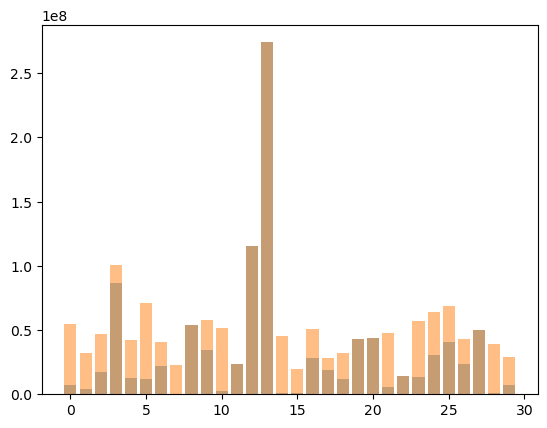

In [69]:
plt.bar(np.arange(max_debts.shape[0]), results[0], alpha=0.5)
plt.bar(np.arange(max_debts.shape[0]), max_debts, alpha=0.5)

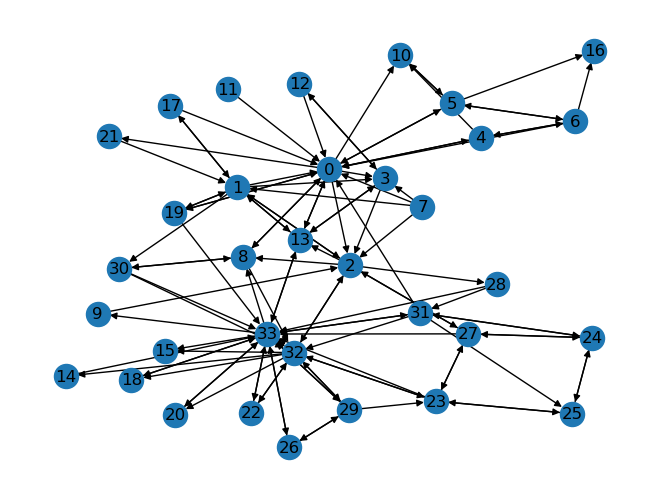

In [162]:
karate_graph = nx.karate_club_graph()

G_dir = karate_graph.to_directed()

for n in G_dir.nodes:
    neighbors = list(set(G_dir.successors(n)) | set(G_dir.predecessors(n)))
    for other in neighbors:
        if (n, other) in G_dir.edges and (other, n) in G_dir.edges:
            p = np.random.rand()
            if p < 0.2:
                G_dir.remove_edge(n, other)
            elif p < 0.4:
                G_dir.remove_edge(other, n)

for u, v, d in G_dir.edges(data=True):
    G_dir.edges[u, v]["capacity"] = d["weight"]
    del G_dir.edges[u, v]["weight"]

nx.draw_kamada_kawai(G_dir, with_labels=True)

In [163]:
balances = np.random.pareto(2.0, size=G_dir.number_of_nodes())
balances = balances / np.sum(balances) * 1000000


<BarContainer object of 34 artists>

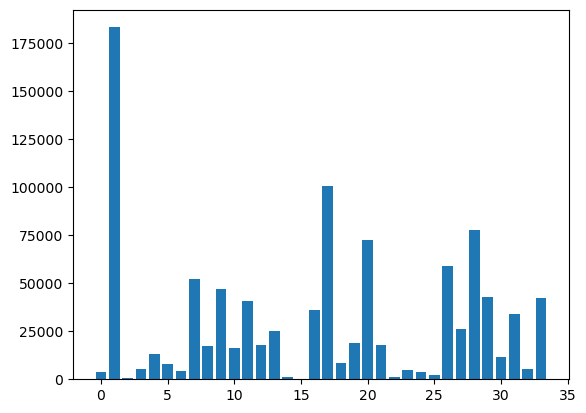

In [164]:
plt.bar(np.arange(len(balances)), balances)

In [165]:
heights_low = balances * 0.3
heights_hi = balances * 1.1

for node in G_dir.nodes:
    for other in G_dir.successors(node):
        G_dir.edges[node, other]["height"] = np.random.uniform(heights_low[node], heights_hi[node])

In [166]:
list(G_dir.edges(data=True))[:4]

[(0, 2, {'capacity': 5, 'height': 3947.6044220784706}),
 (0, 3, {'capacity': 3, 'height': 3464.4610134448367}),
 (0, 4, {'capacity': 3, 'height': 2759.5830543325237}),
 (0, 5, {'capacity': 3, 'height': 4319.300700385576})]

In [167]:
balances_dict = {i: balances[i] for i in range(len(balances))}

In [180]:
results = simulate_vessels(G_dir, balances_dict, n_steps=1000, fractional_banking_coeff=0.9)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 1000, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (1000, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 509.51it/s]

Execution Method: single_proc_exec



Flattening results:   0%|                                   | 1/1001 [00:00<00:01, 644.78it/s]

Total execution time: 5.85s
[32683.22238897 32707.12253689 33017.37685472 32705.47100199
 32856.44036842 32943.59545405 32732.04477973 29830.6797107
 32987.99981247 33249.77521143 32784.86260764 29840.76539659
 32762.65839211 33134.62335061 32791.08986707 33639.48367176
 35805.70187776 32816.16223854 33126.23574049 32840.22515198
 32924.51055014 32768.78814734 32825.13984046 33121.1901732
 32796.17202189 32769.90648947 33009.45813978 32807.91230925
 32745.10189594 33117.12328197 32712.0069788  33081.01991271
 32734.98662172 32690.62856469]


<BarContainer object of 34 artists>

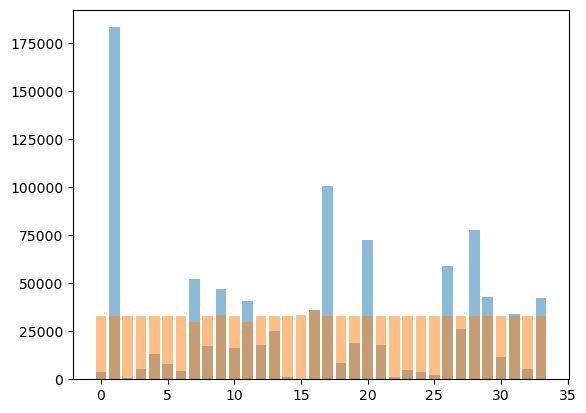

In [181]:
plt.bar(np.arange(results.shape[1]), results[0], alpha=0.5)
plt.bar(np.arange(results.shape[1]), results[-1], alpha=0.5)

In [182]:
print(list(G_dir.predecessors(0)))

results, records = simulate_single_user_debt(G_dir, balances_dict, n_steps=1500, n_user=3)

[1, 4, 5, 6, 7, 8, 11, 12, 13, 17, 19, 31]

                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 1500, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (1500, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 826.79it/s]

Execution Method: single_proc_exec



Flattening results:   0%|                                   | 1/1501 [00:00<00:02, 698.93it/s]

Total execution time: 5.81s
[  3958.69134583  94154.33895878    783.31664741  94214.89472135
  13292.20013606   8167.75276644   4453.16269363  52215.87989912
  17227.11710049  46877.55692727  16008.27019095  40548.03057243
  17882.30241454  24860.52930703   1094.58948776    271.36239919
  35805.70187776 100340.87773531   8568.59889548  18783.50669494
  72279.77261245  17665.52094961   1291.94200979   4919.67625454
   3532.70558462   2396.9117051   58814.50161316  26210.821425
  77683.14901914  42697.76856059  11328.43183998  33931.38353554
   5580.50817485  42158.22594383]


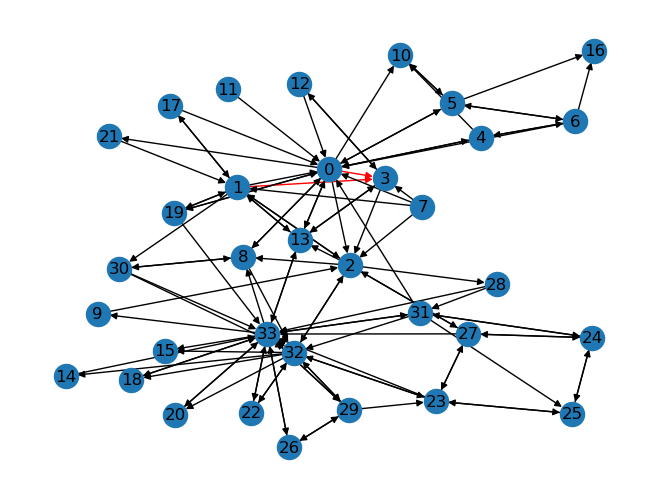

In [183]:
draw_with_edge_colors(records[0][-1]['graph'])

<BarContainer object of 34 artists>

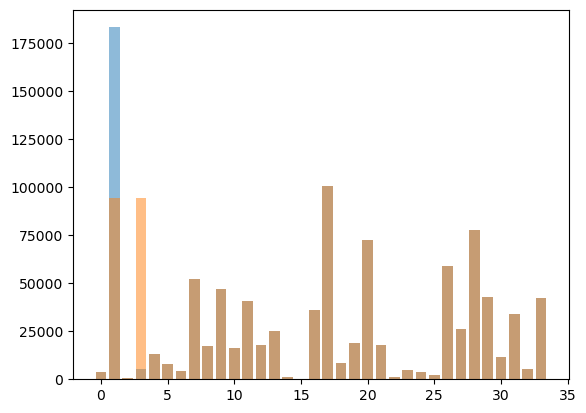

In [184]:
plt.bar(np.arange(results.shape[1]), results[0], alpha=0.5)
plt.bar(np.arange(results.shape[1]), results[-1], alpha=0.5)

In [135]:
np.sum(results[0])

1000000.0000000001

In [136]:
np.sum(results[-1])

999888.7232482631

In [ ]:
def generate_proper_graph_from_balances(balances):
    N = len(balances)

In [4]:
def create_simulation_maxflow2(graph):
    
    num_edges = graph.number_of_edges()
    capacities = list(np.random.randint(1, 10000, num_edges))
    balances = {node: np.random.randint(1, 100000) for node in graph.nodes}
    
    for edge in graph.edges:
        graph.edges[edge]["capacity"] = capacities.pop()
    
    gca = Maxflow2GCA(graph, balance_distribution=balances)
    records = gca.run_simulation(10)
    return records

In [5]:
# Create a Watts-Strogatz graph
n = 1000  # number of nodes
k = 10    # each node is connected to k nearest neighbors in ring topology
p = 0.1   # the probability of rewiring each edge

records = []

graph_1 = nx.barabasi_albert_graph(n, 2, seed=42)
records.append({
    "title": "barabasi_albert_graph",
    "graph": graph_1,
    "records": create_simulation_maxflow2(graph_1)
})


graph_2 = nx.watts_strogatz_graph(n, k, p, seed=42)
records.append({
    "title": "watts_strogatz_graph",
    "graph": graph_2,
    "records": create_simulation_maxflow2(graph_2)
})



                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 10, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (10, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 596.37it/s]

Execution Method: single_proc_exec


AttributeError: 'Graph' object has no attribute 'predecessors'

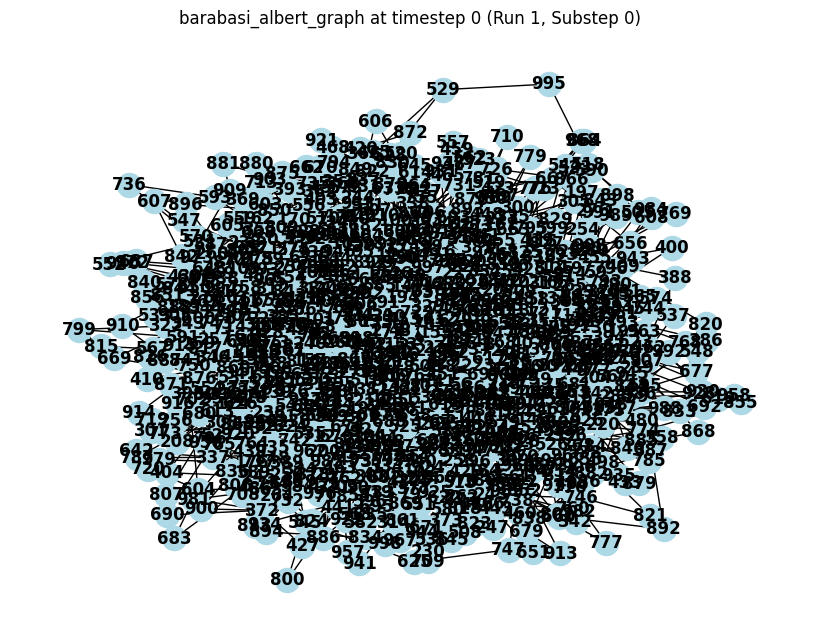

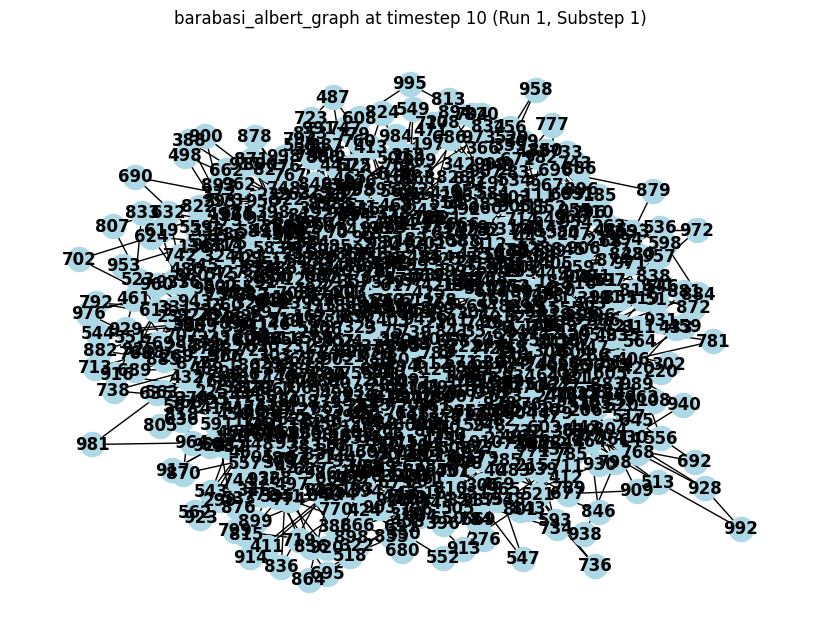

AttributeError: 'Series' object has no attribute 'is_directed'

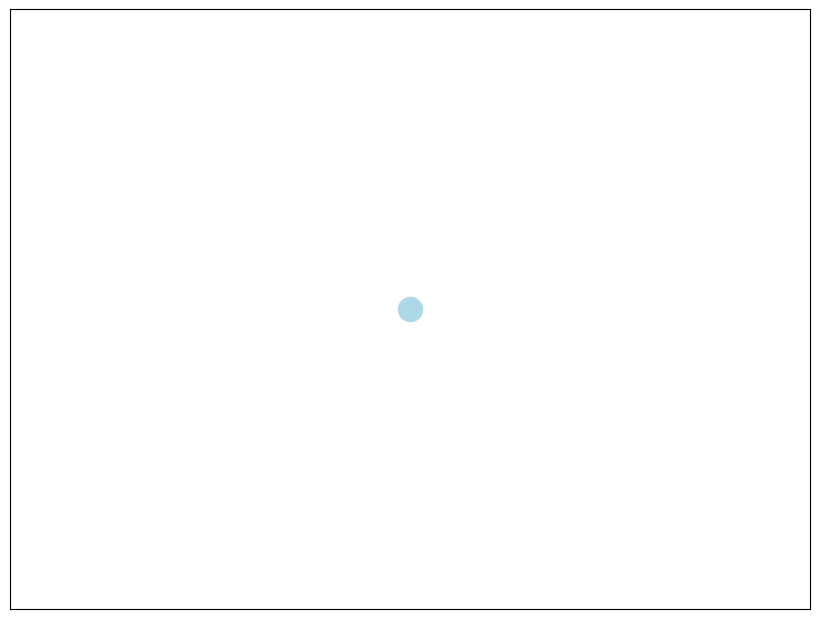

In [63]:

def plot_graph(title, record):
    graph = record['graph']
    plt.figure(figsize=(8, 6))  # Create a new figure for each graph
    nx.draw(graph, with_labels=True, node_color='lightblue', font_weight='bold')
    plt.title(f"{title} at timestep {record['timestep']} (Run {record['run']}, Substep {record['substep']})")
    plt.show()

# Plot each record
for i, record_state in enumerate(records):
    for steps in record_state['records']:
        plot_graph(record_state['title'], steps[0])
        plot_graph(record_state['title'], steps[-1])
    